# RPCA-Enhanced Anomaly Detection on UCSD

Two phases:

**Phase 1 (baseline)** — per-frame ConvAE reconstruction. Establishes the RPCA cache and a weak baseline (~0.67 AUC on Ped2).

**Phase 2 (predictor)** — UNet future-frame prediction with RPCA integrated four ways. Targets SOTA-territory AUC (≥ 0.85). RPCA's value is now testable because the task — predicting motion — is one where background subtraction is unambiguously useful.

Plus an SVD weight-compression ablation (RQ4) on the trained predictor.

In [14]:
import sys, os, time
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_ROOT = PROJECT_ROOT / 'UCSD_Anomaly_Dataset.v1p2'
CACHE_ROOT = PROJECT_ROOT / 'cache'
CKPT_ROOT = PROJECT_ROOT / 'checkpoints'
RESULTS = PROJECT_ROOT / 'results'
for p in (CACHE_ROOT, CKPT_ROOT, RESULTS, RESULTS / 'viz'):
    p.mkdir(parents=True, exist_ok=True)

import numpy as np, torch, matplotlib.pyplot as plt
from src.data import parse_gt_m, list_clips, load_clip_frames, clip_frame_counts
from src.rpca import rpca_clip
from src.cache import precompute_split, load_cached
from src.viz import visualize_decomposition

DEVICE = torch.device('mps' if torch.backends.mps.is_available()
                       else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('device:', DEVICE, '  torch:', torch.__version__)

device: cuda   torch: 2.5.1+cu121


## 1. Data sanity checks

In [13]:
ped = 'UCSDped2'
counts = clip_frame_counts(DATA_ROOT / ped / 'Test', kind='test')
labels = parse_gt_m(DATA_ROOT / ped / 'Test' / f'{ped}.m', n_frames_per_clip=counts)
for i, (c, lab) in enumerate(zip(counts, labels)):
    print(f'  clip {i+1:02d}  T={c:3d}  anom={lab.mean():.2f}  first_anom_idx={int(np.argmax(lab))}')

  clip 01  T=180  anom=0.67  first_anom_idx=60
  clip 02  T=180  anom=0.48  first_anom_idx=94
  clip 03  T=150  anom=0.97  first_anom_idx=0
  clip 04  T=180  anom=0.83  first_anom_idx=30
  clip 05  T=150  anom=0.86  first_anom_idx=0
  clip 06  T=180  anom=0.88  first_anom_idx=0
  clip 07  T=180  anom=0.75  first_anom_idx=45
  clip 08  T=180  anom=1.00  first_anom_idx=0
  clip 09  T=120  anom=1.00  first_anom_idx=0
  clip 10  T=150  anom=1.00  first_anom_idx=0
  clip 11  T=180  anom=1.00  first_anom_idx=0
  clip 12  T=180  anom=0.52  first_anom_idx=87


Train001 (120, 240, 360) float32 min/max: 0.0627451 0.92156863


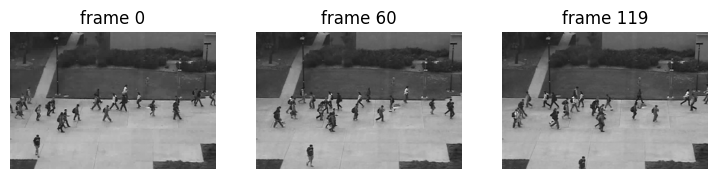

In [12]:
clip_dir = list_clips(DATA_ROOT / 'UCSDped2' / 'Train', kind='train')[0]
frames = load_clip_frames(clip_dir)
print(clip_dir.name, frames.shape, frames.dtype, 'min/max:', frames.min(), frames.max())
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for k, fi in enumerate([0, frames.shape[0]//2, frames.shape[0]-1]):
    ax[k].imshow(frames[fi], cmap='gray'); ax[k].set_title(f'frame {fi}'); ax[k].axis('off')
plt.show()

## 2. RPCA decomposition (single-clip sanity check)

iters=12  residual=8.01e-07  rank=4  time=5.91s


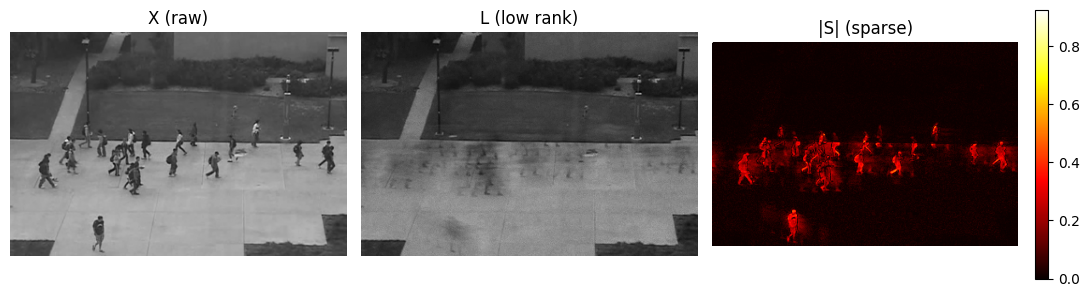

In [15]:
L, S, info = rpca_clip(frames, max_iter=80, tol=1e-6, verbose=False)
print(f'iters={info.iters}  residual={info.final_residual:.2e}  rank={info.rank}  '
      f'time={info.wall_time_s:.2f}s')
fi = frames.shape[0] // 2
fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(frames[fi], cmap='gray', vmin=0, vmax=1); ax[0].set_title('X (raw)')
ax[1].imshow(L[fi], cmap='gray'); ax[1].set_title('L (low rank)')
im = ax[2].imshow(np.abs(S[fi]), cmap='hot'); ax[2].set_title('|S| (sparse)')
plt.colorbar(im, ax=ax[2], fraction=0.04)
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 3. Bulk RPCA preprocessing (cached)

In [6]:
for ped in ('UCSDped2', 'UCSDped1'):
    for split in ('Train', 'Test'):
        diags = precompute_split(DATA_ROOT, CACHE_ROOT, ped, split,
                                 rpca_kwargs={'max_iter': 80, 'tol': 1e-6})
        avg_iter = np.mean([d['iters'] for d in diags])
        max_res = max(d['residual'] for d in diags)
        print(f'  {ped}/{split}: {len(diags):>2} clips, avg_iter={avg_iter:.1f}, '
              f'max_residual={max_res:.2e}')

RPCA UCSDped2/Train: 100%|██████████| 16/16 [03:41<00:00, 13.82s/it]


  UCSDped2/Train: 16 clips, avg_iter=8.7, max_residual=9.79e-07


RPCA UCSDped2/Test: 100%|██████████| 12/12 [03:08<00:00, 15.73s/it]


  UCSDped2/Test: 12 clips, avg_iter=10.2, max_residual=9.98e-07


RPCA UCSDped1/Train: 100%|██████████| 34/34 [04:31<00:00,  7.99s/it]


  UCSDped1/Train: 34 clips, avg_iter=10.3, max_residual=9.93e-07


RPCA UCSDped1/Test:  44%|████▍     | 16/36 [02:18<02:50,  8.52s/it]PackBitsDecode: Not enough data for scanline 0.
/cluster/home/martnal/rpca/src/cache.py:74: RuntimeWarning: corrupt TIFF /cluster/home/martnal/rpca/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test017/142.tif replaced with frame 140 (nearest valid)
  frames = load_clip_frames(clip_dir)  # (T, H, W) float32 [0,1]
RPCA UCSDped1/Test: 100%|██████████| 36/36 [05:10<00:00,  8.61s/it]

  UCSDped1/Test: 36 clips, avg_iter=10.8, max_residual=9.96e-07


## 4. Phase 2 — UNet future-frame predictor across four RPCA variants

Same architecture and hyperparameters across the four variants — only the input/target tensors change. This isolates the contribution of RPCA.

In [7]:
from src.dataset import VARIANTS
from src.train import TrainConfig, train_predictor, load_checkpoint
from src.evaluate import evaluate_run, append_results_csv
from src.viz import plot_roc_overlay

RESULTS_CSV = RESULTS / 'auc_table_v2.csv'
PED = 'UCSDped2'
cfg_p2 = TrainConfig(epochs=100, batch_size=16, lr=2e-4, num_workers=4,
                     val_frac=0.15, early_stop_patience=10, augment=True,
                     lambda_grad=1.0, base_channels=32, window=4, warmup_epochs=3)
ped2_runs = []
for v in VARIANTS:
    ckpt = CKPT_ROOT / f'v2_{PED}_{v}.pt'
    print(f'\n=== {PED} / {v} ===')
    train_predictor(DATA_ROOT, CACHE_ROOT, PED, v, ckpt,
                    cfg=cfg_p2, device=DEVICE)
    model = load_checkpoint(ckpt, device=DEVICE)
    res = evaluate_run(model, DATA_ROOT, CACHE_ROOT, PED, v,
                       device=DEVICE, window=cfg_p2.window, batch_size=16)
    print(f"  AUC_global={res['auc_global']:.4f}  AUC_per_clip={res['auc_per_clip']:.4f}  EER={res['eer']:.4f}")
    append_results_csv(RESULTS_CSV, res)
    ped2_runs.append(res)


=== UCSDped2 / raw ===


[train] UCSDped2/raw: device=cuda params=4,489,857  in_ch=4 out_ch=1
[train] train clips=14 (2164 samples)  val clips=2 (322 samples)
[ep 001] train=0.15733  val=0.09882  lr=6.67e-05  (53.5s)
[ep 002] train=0.08445  val=0.08078  lr=1.33e-04  (38.6s)
[ep 003] train=0.07317  val=0.07596  lr=2.00e-04  (38.6s)
[ep 004] train=0.06526  val=0.07169  lr=2.00e-04  (38.6s)
[ep 005] train=0.05448  val=0.06183  lr=2.00e-04  (38.6s)
[ep 006] train=0.04793  val=0.05351  lr=2.00e-04  (38.5s)
[ep 007] train=0.04647  val=0.05349  lr=2.00e-04  (38.6s)
[ep 008] train=0.04288  val=0.04765  lr=1.99e-04  (38.6s)
[ep 009] train=0.04416  val=0.04642  lr=1.99e-04  (38.6s)
[ep 010] train=0.04067  val=0.04516  lr=1.98e-04  (38.6s)
[ep 011] train=0.03921  val=0.04530  lr=1.97e-04  (38.6s)
[ep 012] train=0.03823  val=0.04744  lr=1.97e-04  (38.5s)
[ep 013] train=0.03925  val=0.04131  lr=1.96e-04  (38.6s)
[ep 014] train=0.03674  val=0.04094  lr=1.95e-04  (38.6s)
[ep 015] train=0.03732  val=0.04081  lr=1.94e-04  (38.

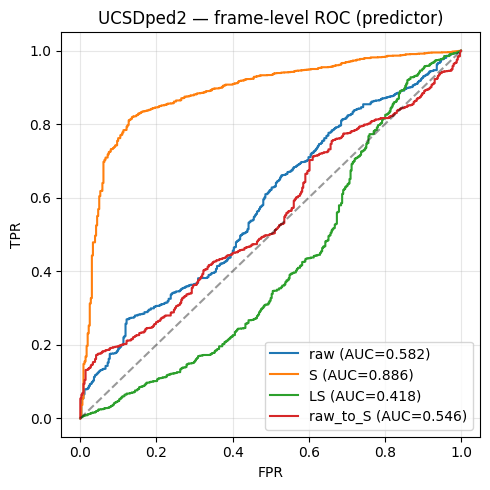

In [8]:
# ROC overlay across the four variants on Ped2.
fig, ax = plt.subplots(figsize=(5, 5))
for r in ped2_runs:
    ax.plot(r['roc_fpr'], r['roc_tpr'],
            label=f"{r['variant']} (AUC={r['auc_global']:.3f})")
ax.plot([0,1], [0,1], 'k--', alpha=0.4); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('UCSDped2 — frame-level ROC (predictor)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS / 'viz' / 'roc_v2_ped2.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Same protocol on Ped1


=== UCSDped1 / raw ===
  found existing checkpoint at v2_UCSDped1_raw.pt — skipping training


  AUC_global=0.7021  AUC_per_clip=0.7713  EER=0.3500

=== UCSDped1 / S ===
[train] UCSDped1/S: device=cuda params=4,489,857  in_ch=4 out_ch=1
[train] train clips=31 (6076 samples)  val clips=3 (588 samples)
[ep 001] train=0.11538  val=0.08454  lr=6.67e-05  (21.3s)
[ep 002] train=0.06566  val=0.07053  lr=1.33e-04  (12.5s)
[ep 003] train=0.06000  val=0.07511  lr=2.00e-04  (12.4s)
[ep 004] train=0.05558  val=0.06643  lr=2.00e-04  (12.5s)
[ep 005] train=0.05358  val=0.06427  lr=2.00e-04  (12.5s)
[ep 006] train=0.05013  val=0.07964  lr=2.00e-04  (12.5s)
[ep 007] train=0.04886  val=0.06531  lr=2.00e-04  (12.5s)
[ep 008] train=0.04724  val=0.05796  lr=1.99e-04  (12.5s)
[ep 009] train=0.04596  val=0.06075  lr=1.99e-04  (12.5s)
[ep 010] train=0.04651  val=0.05523  lr=1.98e-04  (12.5s)
[ep 011] train=0.04329  val=0.05883  lr=1.97e-04  (12.5s)
[ep 012] train=0.04562  val=0.05681  lr=1.97e-04  (12.5s)
[ep 013] train=0.04346  val=0.05928  lr=1.96e-04  (12.5s)
[ep 014] train=0.04218  val=0.05343  lr

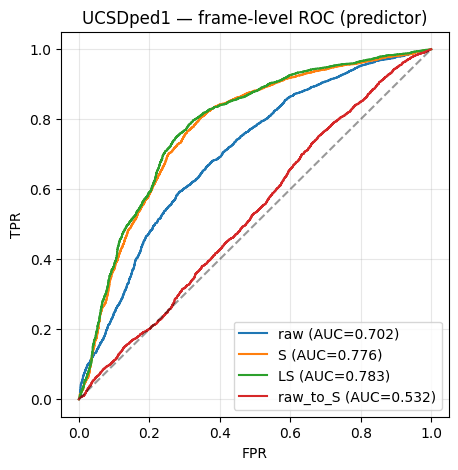

In [21]:
from src.dataset import VARIANTS
from src.train import TrainConfig, train_predictor, load_checkpoint
from src.evaluate import evaluate_run, append_results_csv
from src.viz import plot_roc_overlay

RESULTS_CSV = RESULTS / 'auc_table_v2.csv'
PED = 'UCSDped1'
cfg_p1 = TrainConfig(epochs=100, batch_size=32, lr=2e-4, num_workers=4,
                     val_frac=0.10, early_stop_patience=10, augment=True,
                     lambda_grad=1.0, base_channels=32, window=4, warmup_epochs=3)
ped1_runs = []
for v in VARIANTS:
    ckpt = CKPT_ROOT / f'v2_{PED}_{v}.pt'
    print(f'\n=== {PED} / {v} ===')
    if ckpt.exists():
        print(f'  found existing checkpoint at {ckpt.name} — skipping training')
    else:
        train_predictor(DATA_ROOT, CACHE_ROOT, PED, v, ckpt,
                        cfg=cfg_p1, device=DEVICE)
    model = load_checkpoint(ckpt, device=DEVICE)
    res = evaluate_run(model, DATA_ROOT, CACHE_ROOT, PED, v,
                       device=DEVICE, window=cfg_p1.window, batch_size=32)
    print(f"  AUC_global={res['auc_global']:.4f}  AUC_per_clip={res['auc_per_clip']:.4f}  EER={res['eer']:.4f}")
    append_results_csv(RESULTS_CSV, res)
    ped1_runs.append(res)

fig, ax = plt.subplots(figsize=(5, 5))
for r in ped1_runs:
    ax.plot(r['roc_fpr'], r['roc_tpr'],
            label=f"{r['variant']} (AUC={r['auc_global']:.3f})")
ax.plot([0,1], [0,1], 'k--', alpha=0.4); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('UCSDped1 — frame-level ROC (predictor)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
fig.savefig(RESULTS / 'viz' / 'roc_v2_ped1.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. SVD weight-compression ablation (RQ4)

Truncate every Conv2d weight matrix in the trained UNet at multiple ranks via SVD. The resulting AUC-vs-compression curve quantifies how much of the model's discriminative capacity actually lives in the top singular directions of its weights — a direct demonstration of SVD as model compression, complementing SVD's role inside RPCA's singular-value-thresholding step.

In [22]:
from src.svd_compression import evaluate_compression_curve, append_compression_csv
from src.train import load_checkpoint
import pandas as pd

# Pick the best Ped2 variant from the AUC table on disk (standalone — does not depend on cell 4).
RESULTS_CSV = RESULTS / 'auc_table_v2.csv'
_df = pd.read_csv(RESULTS_CSV)
_ped2 = _df[_df['ped'] == 'UCSDped2']
best = _ped2.loc[_ped2['auc_global'].idxmax()]
PED, V = 'UCSDped2', best['variant']
print(f'compressing {PED}/{V} (AUC={best["auc_global"]:.4f})')
model = load_checkpoint(CKPT_ROOT / f'v2_{PED}_{V}.pt', device=DEVICE)
rows = evaluate_compression_curve(
    model, DATA_ROOT, CACHE_ROOT, PED, V, device=DEVICE,
    rank_fracs=(1.0, 0.75, 0.5, 0.25, 0.1), window=4, batch_size=16,
)
append_compression_csv(RESULTS / 'svd_compression.csv', PED, V, rows)
df_svd = pd.DataFrame(rows)
print(df_svd[['rank_frac','compression_ratio','auc_global','auc_per_clip']].to_string(index=False))


compressing UCSDped2/S (AUC=0.8864)
 rank_frac  compression_ratio  auc_global  auc_per_clip
      1.00           1.115175    0.885325      0.941386
      0.75           0.836809    0.374408      0.327785
      0.50           0.558443    0.697031      0.672075
      0.25           0.280077    0.284232      0.379006
      0.10           0.114380    0.715253      0.690500


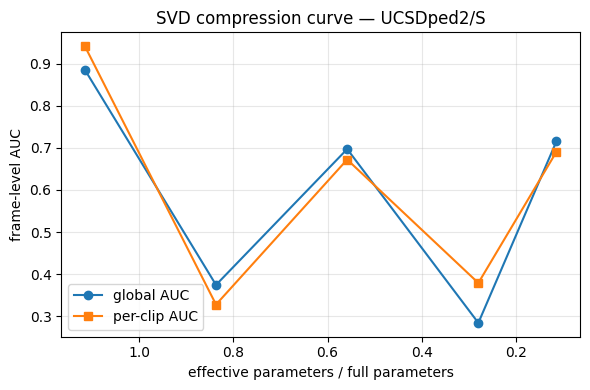

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_svd['compression_ratio'], df_svd['auc_global'], 'o-', label='global AUC')
ax.plot(df_svd['compression_ratio'], df_svd['auc_per_clip'], 's-', label='per-clip AUC')
ax.set_xlabel('effective parameters / full parameters')
ax.set_ylabel('frame-level AUC')
ax.set_title(f'SVD compression curve — {PED}/{V}')
ax.invert_xaxis()
ax.grid(alpha=0.3); ax.legend(loc='lower left')
fig.tight_layout(); fig.savefig(RESULTS / 'viz' / 'svd_compression.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Final summary — Phase 1 vs Phase 2

In [25]:
import pandas as pd

RESULTS_CSV = RESULTS / 'auc_table_v2.csv'
df_v2 = pd.read_csv(RESULTS_CSV)
df_v2 = df_v2.sort_values(['ped','variant']).reset_index(drop=True)
print('=== Phase 2 (predictor) ===')
print(df_v2[['ped','variant','auc_global','auc_per_clip','eer']].to_string(index=False))
df_v2.to_markdown(RESULTS / 'auc_table_v2.md', index=False)

phase1 = RESULTS / 'auc_table.csv'
if phase1.exists():
    df_v1 = pd.read_csv(phase1)
    print('\n=== Phase 1 (per-frame AE, for comparison) ===')
    print(df_v1[['ped','representation','auc_mean']].to_string(index=False))
df_v2


=== Phase 2 (predictor) ===
     ped  variant  auc_global  auc_per_clip      eer
UCSDped1       LS    0.783413      0.824150 0.265844
UCSDped1        S    0.776007      0.814114 0.276953
UCSDped1      raw    0.702120      0.771271 0.350026
UCSDped1      raw    0.702120      0.771271 0.350026
UCSDped1 raw_to_S    0.531539      0.594145 0.485840
UCSDped2       LS    0.418130      0.490305 0.583305
UCSDped2        S    0.886436      0.941604 0.164016
UCSDped2      raw    0.581783      0.684813 0.453932
UCSDped2 raw_to_S    0.546059      0.545955 0.498012


,ped,variant,n_frames,frac_anom,auc_global,auc_per_clip,eer
0,UCSDped1,LS,7200,0.561806,0.783413,0.824150,0.265844
1,UCSDped1,S,7200,0.561806,0.776007,0.814114,0.276953
2,UCSDped1,raw,7200,0.561806,0.702120,0.771271,0.350026
3,UCSDped1,raw,7200,0.561806,0.702120,0.771271,0.350026
4,UCSDped1,raw_to_S,7200,0.561806,0.531539,0.594145,0.485840
5,UCSDped2,LS,2010,0.819900,0.418130,0.490305,0.583305
6,UCSDped2,S,2010,0.819900,0.886436,0.941604,0.164016
7,UCSDped2,raw,2010,0.819900,0.581783,0.684813,0.453932
8,UCSDped2,raw_to_S,2010,0.819900,0.546059,0.545955,0.498012


## 8. Qualitative L/S decomposition figures

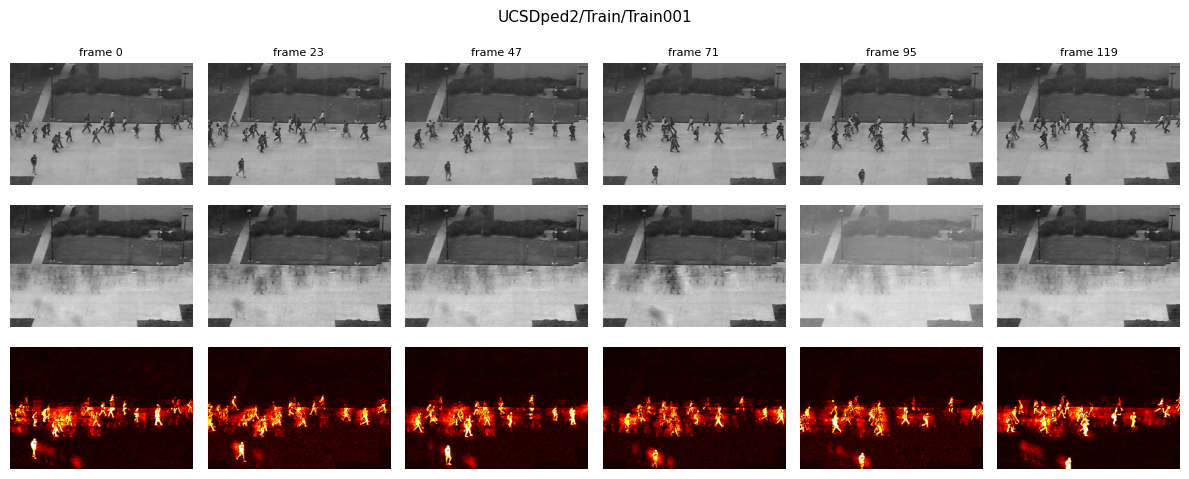

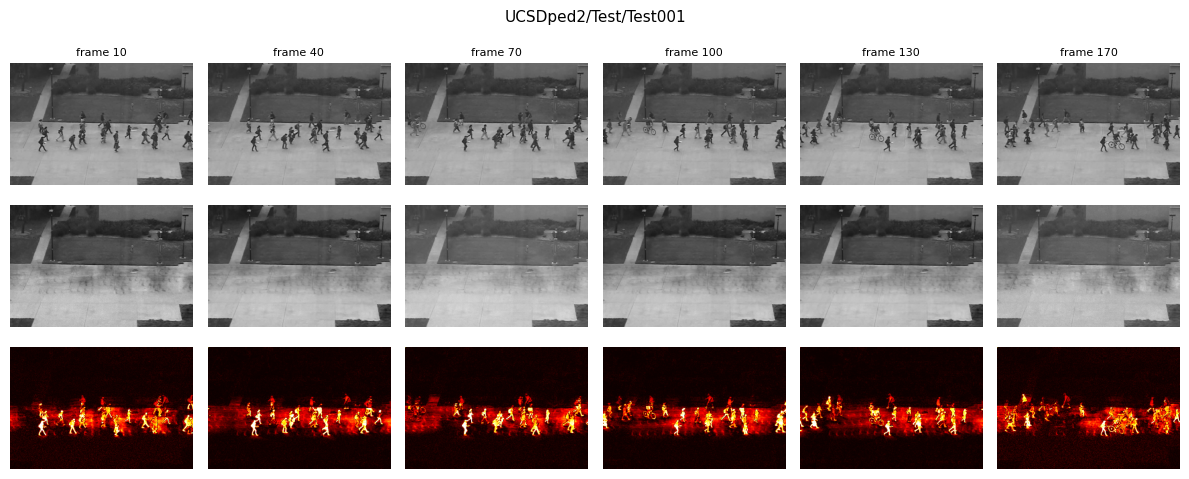

In [26]:
_ = visualize_decomposition(CACHE_ROOT, 'UCSDped2', 'Train', 'Train001',
                            save_path=RESULTS / 'viz' / 'ped2_train001_decomp.png')
_ = visualize_decomposition(CACHE_ROOT, 'UCSDped2', 'Test', 'Test001',
                            frame_indices=[10, 40, 70, 100, 130, 170],
                            save_path=RESULTS / 'viz' / 'ped2_test001_decomp.png')
plt.show()